# Schema_skrf Component Tutorial

This tutorial demonstrates how to use various components in Schema_skrf. We'll cover:

1. Basic Components (RLGC)
2. Microwave Components
3. Simulation Components
4. Working with Different Media Types
5. Creating Circuits with Components

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
path = str(Path.cwd().parent)
if path not in sys.path:
    sys.path.append(path)
from Src.Models.Component import *
from Src.Models.Media import *

# Create a frequency range for our examples
freq = np.linspace(1e9, 10e9, 101)  # 1-10 GHz, 101 points

## 1. Basic Components (RLGC)

Let's start with the basic RLGC components: Resistor (R), Inductor (L), Conductor (G), and Capacitor (C).

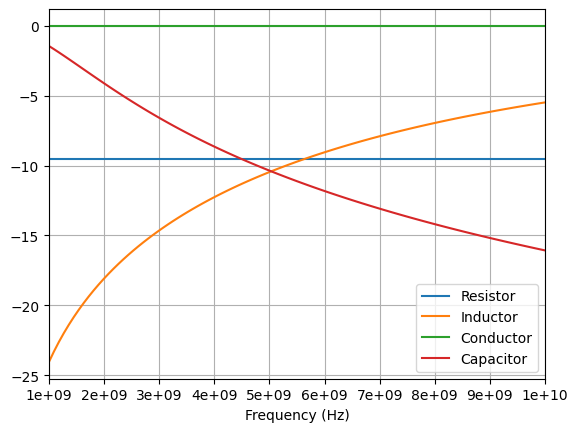

In [2]:
# Create basic components
resistor = R(frequency=freq, r=50)  # 50Ω resistor
inductor = L(frequency=freq, l=1e-9)  # 1nH inductor
conductor = G(frequency=freq, g=0.02)  # 0.02S conductor
capacitor = C(frequency=freq, c=1e-12)  # 1pF capacitor

# Convert to networks and plot S-parameters
r_network = resistor.to_network()
l_network = inductor.to_network()
g_network = conductor.to_network()
c_network = capacitor.to_network()

# Plot S11 for each component
r_network.plot_s_db(m=0, n=0, label='Resistor')
l_network.plot_s_db(m=0, n=0, label='Inductor')
g_network.plot_s_db(m=0, n=0, label='Conductor')
c_network.plot_s_db(m=0, n=0, label='Capacitor')
plt.legend()
plt.grid(True)

## 2. Microwave Components

Now let's explore microwave components: Attenuator, Isolator, Splitter, and Coupler.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/skrf/mathFunctions.py:268: RuntimeWarning: divide by zero encountered in log10
  out = 20 * npy.log10(z)


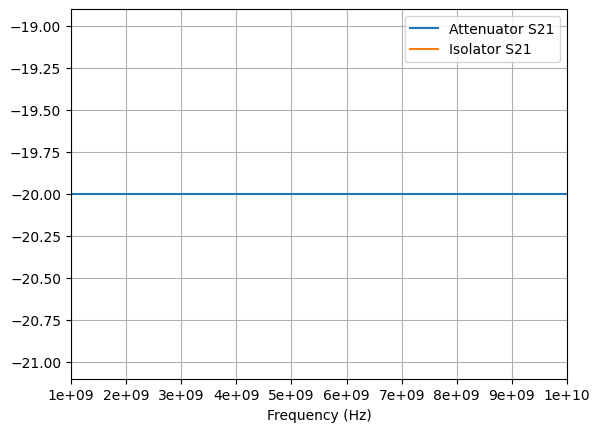

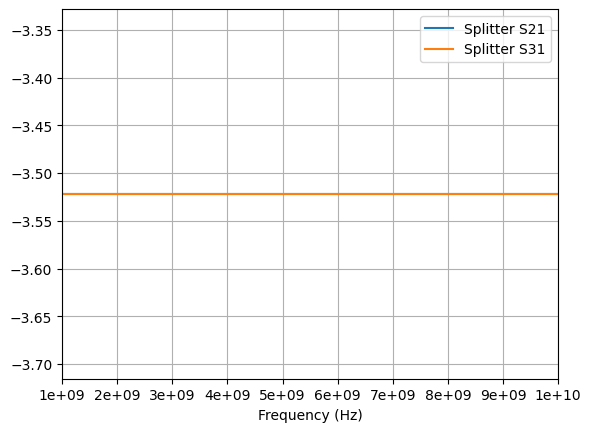

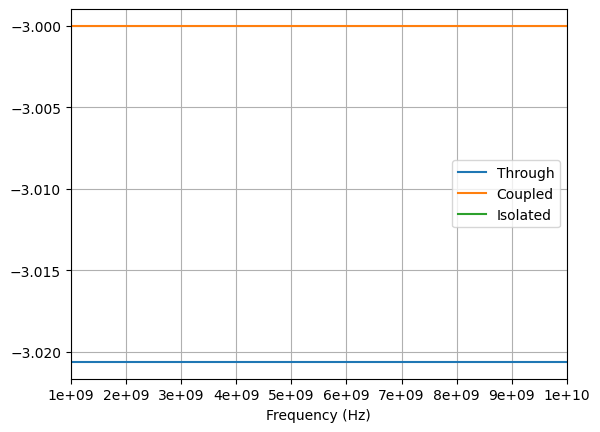

In [3]:
# Create microwave components
attenuator = Attenuator(frequency=freq, s21=-20)  # -20dB attenuator
isolator = Isolator(frequency=freq)  # Default isolation >60dB
splitter = Splitter(frequency=freq, nports=3)  # 3-way splitter
coupler = Coupler(frequency=freq)  # 10dB coupler

# Convert to networks
att_network = attenuator.to_network()
iso_network = isolator.to_network()
spl_network = splitter.to_network()
cpl_network = coupler.to_network()

# Plot insertion loss for attenuator and isolator
plt.figure()
att_network.plot_s_db(m=1, n=0, label='Attenuator S21')
iso_network.plot_s_db(m=0, n=1, label='Isolator S21')
plt.legend()
plt.grid(True)

# Plot power division for splitter
plt.figure()
for i in range(1, splitter.nports):
    spl_network.plot_s_db(m=i, n=0, label=f'Splitter S{i+1}1')
plt.legend()
plt.grid(True)

# Plot coupler characteristics
plt.figure()
cpl_network.plot_s_db(m=1, n=0, label='Through')
cpl_network.plot_s_db(m=2, n=0, label='Coupled')
cpl_network.plot_s_db(m=3, n=0, label='Isolated')
plt.legend()
plt.grid(True)

## 3. Simulation Components

Let's look at simulation components: Port, Ground, and Open.

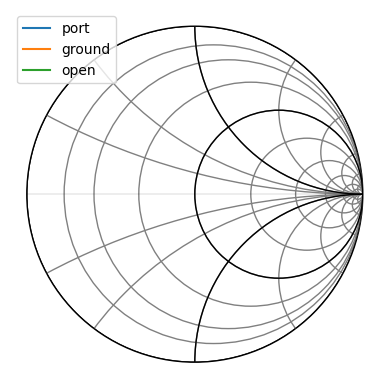

In [4]:
# Create simulation components
port = Port(frequency=freq, z0_port=50, name='port')  # 50Ω port
ground = Ground(frequency=freq, name='ground')  # Ground termination
open_ckt = Open(frequency=freq, name='open')  # Open circuit

# Convert to networks
port_network = port.to_network()
ground_network = ground.to_network()
open_network = open_ckt.to_network()

# Plot reflection coefficients
plt.figure()
port_network.plot_s_smith(m=0, n=0, label=port.name)
ground_network.plot_s_smith(m=0, n=0, label=ground.name)
open_network.plot_s_smith(m=0, n=0, label=open_ckt.name)
plt.legend()

## 4. Working with Different Media Types

Components can be used with various transmission line media. Let's see some examples.

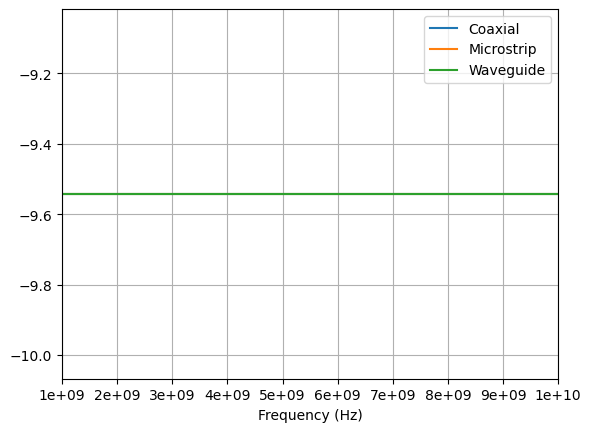

In [5]:
# Create different media types
coax = CoaxialLine(frequency=freq, dinner=0.5e-3, douter=2e-3)
mstrip = MicrostripLine(frequency=freq, w=1e-3, h=0.5e-3, t=35e-6, ep_r=4.4)
rwg = RWG(frequency=freq, a=20e-3, b=10e-3)

# Create a resistor and view it through different media
resistor = R(frequency=freq, r=50)

# Convert to networks with different media
r_coax = resistor.to_network(media=coax)
r_mstrip = resistor.to_network(media=mstrip)
r_rwg = resistor.to_network(media=rwg)

# Plot S-parameters
plt.figure()
r_coax.plot_s_db(m=0, n=0, label='Coaxial')
r_mstrip.plot_s_db(m=0, n=0, label='Microstrip')
r_rwg.plot_s_db(m=0, n=0, label='Waveguide')
plt.legend()
plt.grid(True)

## 5. Creating Circuits with Components

Finally, let's see how to combine components into circuits.

Text(0.5, 1.0, 'Matching Network Response')

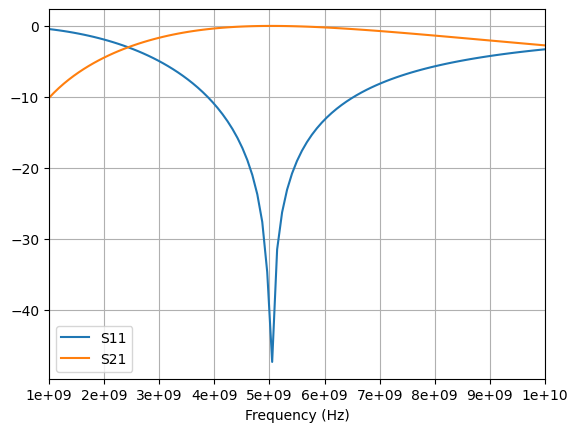

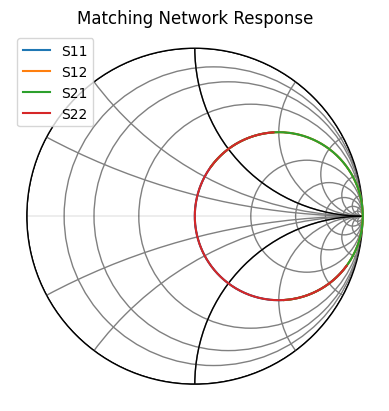

In [6]:
# Create a simple matching network with L and C
l_match = L(frequency=freq, l=2e-9)  # 2nH inductor
c_match = C(frequency=freq, c=0.5e-12)  # 0.5pF capacitor

# Convert to networks
l_net = l_match.to_network()
c_net = c_match.to_network()

# Cascade the networks
match_network = l_net ** c_net

# Plot the response
plt.figure()
match_network.plot_s_db(m=0, n=0, label='S11')
match_network.plot_s_db(m=1, n=0, label='S21')
plt.legend()
plt.grid(True)

# Plot on Smith chart
plt.figure()
match_network.plot_s_smith()
plt.title('Matching Network Response')